In [3]:
import intake
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import matplotlib.pyplot as plt
from dask.distributed import Client
import logging
import xarray as xr
import numpy as np
import warnings
from pint import application_registry as ureg
import cartopy.crs as ccrs

warnings.filterwarnings('ignore')

In [45]:
catalog = intake.cat.access_nri

In [3]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37245,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 125.19 GiB
Comm: tcp://127.0.0.1:39369,Total threads: 4
Dashboard: /proxy/39731/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:45421,


2025-05-30 09:42:51,183 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:36179' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'_open_dataset-9a63f3f1-645f-4823-b503-5af3dc55232b'} (stimulus_id='handle-worker-cleanup-1748562171.1832633')
2025-05-30 09:42:51,226 - distributed.nanny - WARNING - Restarting worker
2025-05-30 09:44:13,765 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'tcp://127.0.0.1:40591'.


In [3]:
def calc_transport_from_dataset(ds, strait, component='zonal'):
    """
    Calculate transport from a pre-loaded dataset (tx_trans or ty_trans).
    
    Parameters:
        ds: xarray.Dataset - should contain tx_trans or ty_trans
        strait: tuple - (xmin, xmax, ymin, ymax)
        component: 'zonal' or 'meridional'
    """
    xmin, xmax, ymin, ymax = strait
    ρ0 = 1036 * ureg.kilogram / ureg.meter**3 # reference density

    if component == 'zonal':
        # Mean over time and select surface layer
        tx_trans = ds['tx_trans'].sum('st_ocean')
        tx_trans = tx_trans.sel(xu_ocean=xmin, method='nearest')\
                           .sel(yt_ocean=slice(ymin, ymax))\
                           .sum('yt_ocean')
        tx_trans = tx_trans.pint.quantify('kg/s')
        transport = (tx_trans / ρ0).pint.to('sverdrup')
    
    elif component == 'meridional':
        ty_trans = ds['ty_trans'].mean('st_ocean')
        ty_trans = ty_trans.sel(yu_ocean=ymin, method='nearest')\
                           .sel(xt_ocean=slice(xmin, xmax))\
                           .sum('xt_ocean')
        ty_trans = ty_trans.pint.quantify('kg/s')
        transport = (ty_trans / ρ0).pint.to('sverdrup')
    else:
        raise ValueError("component must be 'zonal' or 'meridional'")
    transport = transport.compute()
    return transport

In [42]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-3d-ty_trans-1monthly-mean-ym_*.nc
ds_after_change_ty = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
area_2d = xr.open_mfdataset('/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output060/ocean/ocean-2d-area_t.nc', coords = "minimal", compat="override",engine="netcdf4")

In [4]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-3d-tx_trans-1yearly-mean-ym_*.nc
ds_after_change_tx = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
area_2d = xr.open_mfdataset('/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output060/ocean/ocean-2d-area_t.nc', coords = "minimal", compat="override",engine="netcdf4")

In [6]:
Before_Change_PATH = ! ls /scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output*/ocean/ocean-3d-ty_trans-1monthly-mean-ym_*.nc
ds_before_change = xr.open_mfdataset(Before_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
area_2d = xr.open_mfdataset('/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output060/ocean/ocean-2d-area_t.nc', coords = "minimal", compat="override",engine="netcdf4")

In [7]:
Before_Change_PATH

['/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output000/ocean/ocean-3d-ty_trans-1monthly-mean-ym_0942_01.nc',
 '/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output001/ocean/ocean-3d-ty_trans-1monthly-mean-ym_0943_01.nc',
 '/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output002/ocean/ocean-3d-ty_trans-1monthly-mean-ym_0944_01.nc',
 '/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output003/ocean/ocean-3d-ty_trans-1monthly-mean-ym_0945_01.nc',
 '/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output004/ocean/ocean-3d-ty_trans-1monthly-mean-ym_0946_01.nc',
 '/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output005/ocean/ocean-3d-ty_trans-1monthly-mean-ym_0947_01.nc',
 '/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output006/ocea

In [ ]:
# surface_salt = ds_before_change["surface_salt"]; #Sea surface salinity restoring
# cell_area = area_2d["area_t"]

In [21]:
# Calculate zonal transport

strait = (10,  14.5, 37.5, 37.5)  # Strait of Sicily
transport_ty = calc_transport_from_dataset(ds_after_change_ty, strait, component='meridional')

NameError: name 'calc_transport_from_dataset' is not defined

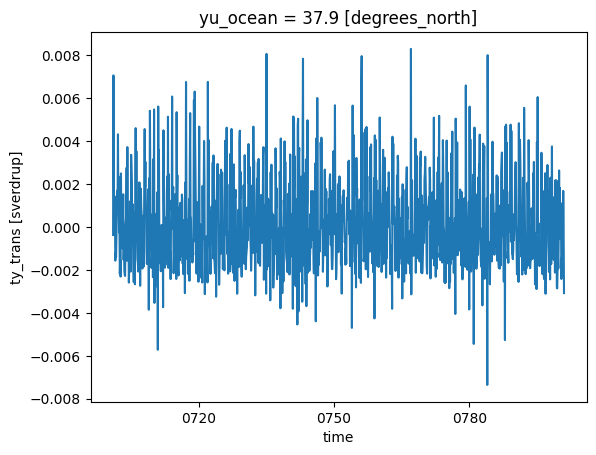

In [ ]:
transport_ty.plot()

In [ ]:
strait = (13,  13, 36, 39)  # Strait of Sicily
transport_tx = calc_transport_from_dataset(ds_after_change_tx, strait, component='zonal')

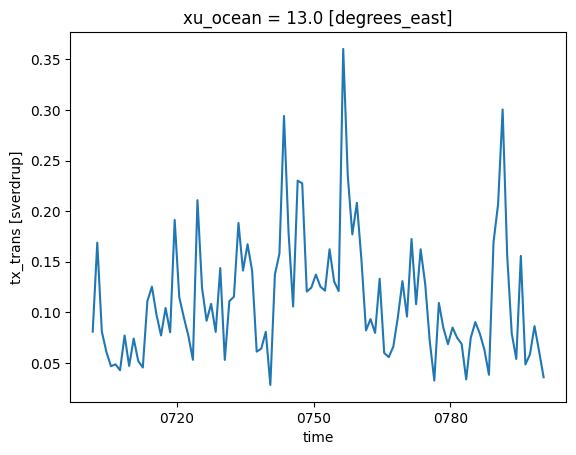

In [ ]:
transport_tx.plot()

In [5]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-2d-sfc_salt_flux_runoff-1monthly-mean-ym_*.nc
salt_flux_after_change_ty = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
area_2d = xr.open_mfdataset('/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output060/ocean/ocean-2d-area_t.nc', coords = "minimal", compat="override",engine="netcdf4")

In [6]:
salt_flux = salt_flux_after_change_ty.sfc_salt_flux_runoff*area_2d.area_t

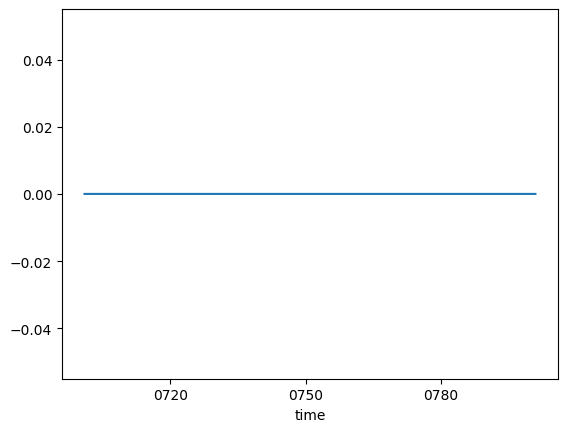

In [ ]:
#Med Sea
lat0=30  # map edge
lat1=31  # average edge
lat2=41  # average edge
lat3=47  # map edge
lon0=-10
lon1=0
lon2=35
lon3=42

salt_restore_OMIP = (salt_flux).sel(xt_ocean=slice(lon1,lon2)).sum('xt_ocean').sel(yt_ocean=slice(lat1,lat2)).sum('yt_ocean')
salt_restore_OMIP.plot(label="Med Sea")

In [32]:
after_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-3d-v-1monthly-mean-ym_*.nc
v_after_change = xr.open_mfdataset(after_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")

In [33]:
v = v_after_change.v.mean('time')

In [34]:
xmin, xmax, ymin, ymax = strait
v= v.sel(yu_ocean=ymin, method='nearest')\
                           .sel(xu_ocean=slice(xmin, xmax))\
                           .sum('xu_ocean')

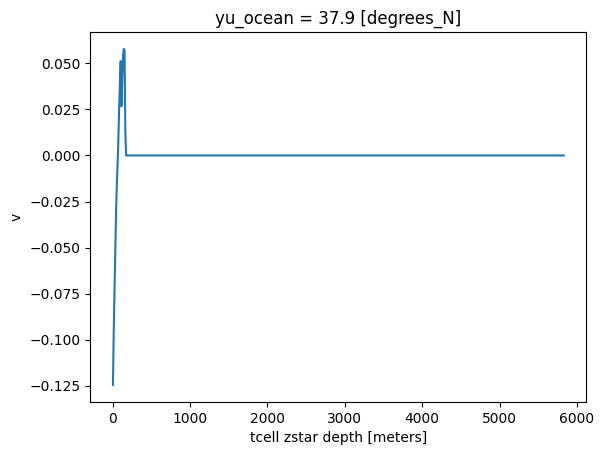

In [35]:
v.plot()

In [36]:
after_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-3d-salt-1monthly-mean-ym_*.nc
Salt_after_change = xr.open_mfdataset(after_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")

In [37]:
Salt = Salt_after_change.salt.interp(xt_ocean=v_after_change.xu_ocean, yt_ocean=v_after_change.yu_ocean, method="nearest")

In [43]:
SV = Salt*v_after_change.v*area_2d.area_t

In [44]:
SV_mean_zonal_average = SV.mean('time').sel(yu_ocean=ymin, method='nearest')\
                           .sel(xu_ocean=slice(xmin, xmax))\
                           .sum('xu_ocean')

In [ ]:
SV_mean_zonal_average.plot(xlim=(0,500))

In [ ]:
v_after_change

In [ ]:
v_integrated_z_mean_time = v_after_change.v.mean("st_ocean").mean('time')

In [ ]:
v_max = v_integrated_z_mean_time.min()
print(v_max.values)

In [ ]:
v_integrated_z_mean_time.plot(xlim=(-10,40),ylim=(25,50), vmin=-0.1, vmax=0.1)

In [ ]:
sv_integrated_z_mean_time = SV.mean("st_ocean").mean('time')

In [ ]:
sv_integrated_z_mean_time.plot(xlim=(-10,40),ylim=(25,50), vmin=-1, vmax=2)

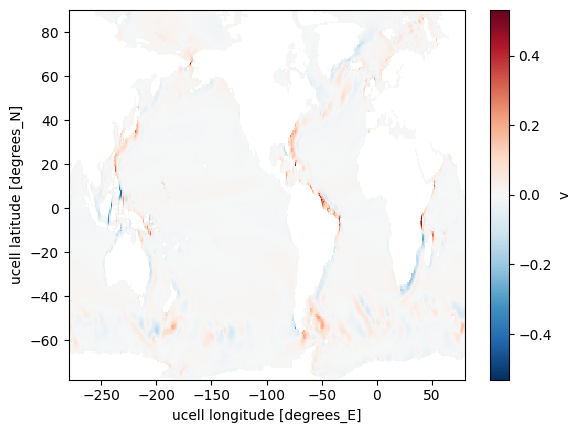

In [ ]:
v_integrated_z_mean_time.plot()

In [ ]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-2d-sfc_salt_flux_runoff-1monthly-mean-ym_*.nc
sfc_salt_flux_runoff = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
area_2d = xr.open_mfdataset('/scratch/p66/pjb581/access-esm/archive/pi_concentrations_test3-restart-840-35bbe5a7/output060/ocean/ocean-2d-area_t.nc', coords = "minimal", compat="override",engine="netcdf4")

In [ ]:
area_2d = area_2d.area_t

In [ ]:
sfc_salt_flux_runoff = sfc_salt_flux_runoff.sfc_salt_flux_runoff*area_2d

In [ ]:
sfc_salt_flux_runoff = sfc_salt_flux_runoff.mean('time')

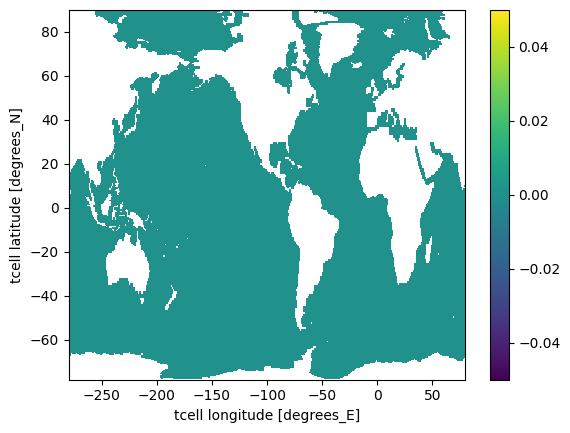

In [ ]:
sfc_salt_flux_runoff.plot()#(xlim=(-10,40),ylim=(25,50),vmin=-0.01, vmax=0.01)

In [7]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-3d-salt_xflux_adv-1yearly-mean-ym_*.nc
sfc_salt_x_flux = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")

In [8]:
salt_xflux_adv = sfc_salt_x_flux.salt_xflux_adv.mean('time').mean('st_ocean')

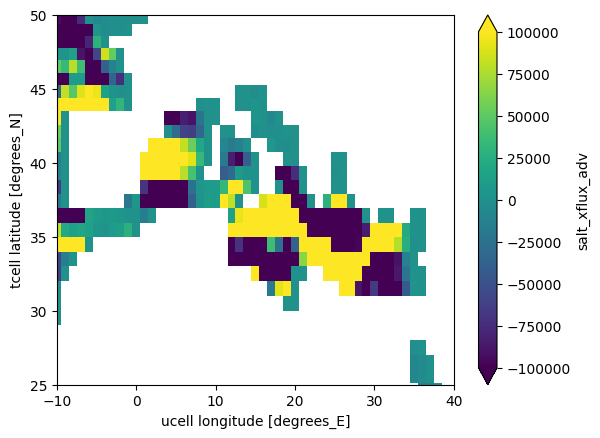

In [9]:
salt_xflux_adv.plot(xlim=(-10,40),ylim=(25,50),vmin = -100000, vmax = 100000)

In [ ]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-3d-salt_yflux_adv-1yearly-mean-ym_*.nc
sfc_salt_y_flux = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
salt_yflux_adv = sfc_salt_y_flux.salt_yflux_adv.mean('time').mean('st_ocean')

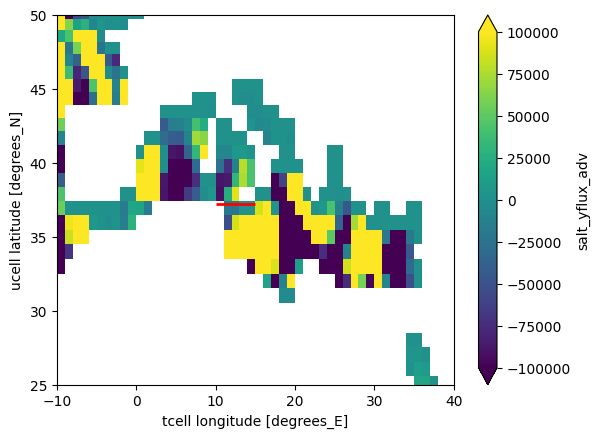

In [ ]:
salt_yflux_adv.plot(xlim=(-10,40),ylim=(25,50),vmin = -100000, vmax = 100000)
# Add a red horizontal line at y = 37.2 from x = 10 to x = 15
plt.hlines(y=37.2, xmin=10, xmax=15, colors='red', linewidth=2)
plt.savefig('/g/data1a/tm70/ek4684/ESM_1_6_plots/salt_yflux_adv_plot.png', dpi=300, bbox_inches='tight')

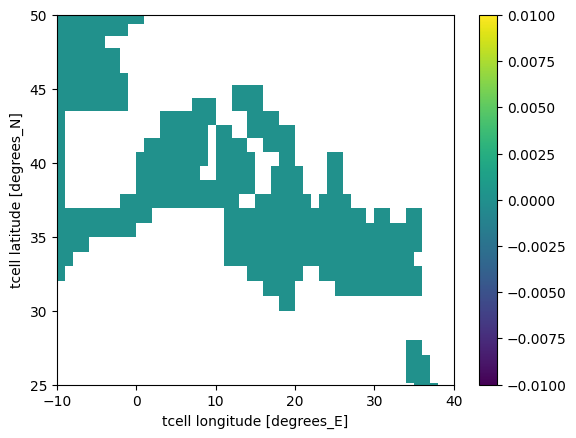

In [ ]:
sfc_salt_flux_runoff.plot(vmin=-0.01, vmax=0.01, xlim=(-10,40),ylim=(25,50))

In [ ]:
After_Change_PATH = ! ls /scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output6*/ocean/ocean-2d-river-1monthly-mean-ym_*
river_runoff_mass_flux = xr.open_mfdataset(After_Change_PATH, coords = "minimal", compat="override",engine="netcdf4")
river_runoff_mass_flux = river_runoff_mass_flux.river.mean('time')

In [51]:
river_runoff_mass_flux = river_runoff_mass_flux*area_2d

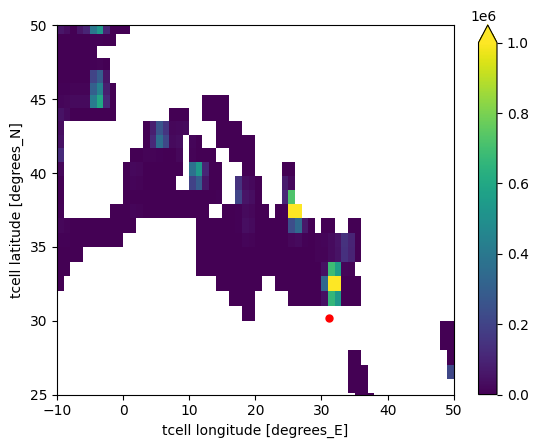

In [52]:
fig, ax = plt.subplots()
river_runoff_mass_flux.plot(xlim=(-10,50),ylim=(25,50),vmin = 0, vmax = 1000000)
ax.plot(31.14, 30.1725, marker='o', color='red', markersize=5)
plt.savefig('/g/data1a/tm70/ek4684/ESM_1_6_plots/mass_flux_of_river_entering_ocean_kg_s.png', dpi=300, bbox_inches='tight')

In [53]:
catalog.df.model.unique()

array([('BNU-ESM',), ('CCCma-CanESM2',), ('CCSM4',), ('CESM1-BGC',),
       ('CESM1-CAM5',), ('CESM1-CAM5-1-FV2',), ('CESM1-FASTCHEM',),
       ('CESM1-WACCM',), ('CFSv2-2011',), ('CMCC-CESM',), ('CMCC-CM',),
       ('CMCC-CMS',), ('CNRM-CERFACS-CNRM-CM5',), ('CNRM-CM5',),
       ('CNRM-CM5-2',), ('CSIRO-BOM-ACCESS1-0',),
       ('CSIRO-QCCCE-CSIRO-Mk3-6-0',), ('CanAM4',), ('CanCM4',),
       ('CanESM2',), ('EC-EARTH',), ('ECMWF-ERAINT',), ('FGOALS-g2',),
       ('FGOALS-gl',), ('FGOALS-s2',), ('FIO-ESM',), ('GEOS-5',),
       ('GFDL-CM2p1',), ('GFDL-CM3',), ('GFDL-ESM2G',), ('GFDL-ESM2M',),
       ('GFDL-HIRAM-C180',), ('GFDL-HIRAM-C360',), ('GISS-E2-H',),
       ('GISS-E2-H-CC',), ('GISS-E2-R',), ('GISS-E2-R-CC',), ('HadCM3',),
       ('HadGEM2-A',), ('HadGEM2-AO',), ('HadGEM2-CC',), ('HadGEM2-ES',),
       ('ICHEC-EC-EARTH',), ('IPSL-CM5A-LR',), ('IPSL-CM5A-MR',),
       ('IPSL-CM5B-LR',), ('IPSL-IPSL-CM5A-LR',), ('IPSL-IPSL-CM5A-MR',),
       ('MIROC-ESM',), ('MIROC-ESM-CHEM',), ('

In [18]:
catalog.search(model="ACCESS-OM2", variable="salt_yflux_adv")

,model,description,realm,frequency,variable
name,,,,,
01deg_jra55v140_iaf_cycle3,{ACCESS-OM2},{Cycle 3 of 0.1 degree ACCESS-OM2 global model configuration with JRA55-do v1.4.0 OMIP2 interannual forcing},{ocean},{1mon},{salt_yflux_adv}
01deg_jra55v140_iaf_cycle4,{ACCESS-OM2},{Cycle 4 of 0.1 degree ACCESS-OM2 global model configuration with JRA55-do v1.4.0 OMIP2 interannual forcing},{ocean},{1mon},{salt_yflux_adv}
01deg_jra55v140_iaf_cycle4_jra55v150_extension,{ACCESS-OM2},{Extensions of cycle 4 of 0.1 degree ACCESS-OM2 + WOMBAT BGC global model configuration with JRA55-do v1.5.0 and v1.5.0.1 interannual forcing},{ocean},{1mon},{salt_yflux_adv}


In [4]:
experiment = "01deg_jra55v140_iaf_cycle4_jra55v150_extension"
variable = "salt_yflux_adv"
ACCESS_OM2_salt_yflux_adv = catalog[experiment].search(
    variable=variable).to_dask()

In [11]:
ACCESS_OM2_salt_yflux_adv= ACCESS_OM2_salt_yflux_adv.salt_yflux_adv.mean('time').mean('st_ocean')

In [12]:
catalog.search(model="ACCESS-CM2", variable="salt_*")

,model,description,realm,frequency,variable
name,,,,,
bx944,{ACCESS-CM2},"{Standard CMIP6 historical simulation, control experiment for by473 pacemaker experiment (948d8676-2c56-49db-8ea1-b80572b074c8)}",{ocean},{1mon},"{salt_yflux_ndiffuse, salt_xflux_gm, salt_merid_flux_gyre_atlantic, salt_xflux_adv, salt_vdiffuse_diff_cbt, salt_vdiffuse_diff_cbt_conv, salt_calvingmix, salt_tendency_expl, salt_merid_flux_advect..."
by473,{ACCESS-CM2},"{Pacemaker variation of CMIP6 historical simulation, Topical Atlantic region replaced with fixed SSTs from observations}",{ocean},{1mon},"{salt_yflux_ndiffuse, salt_xflux_gm, salt_merid_flux_gyre_atlantic, salt_xflux_adv, salt_vdiffuse_diff_cbt, salt_vdiffuse_diff_cbt_conv, salt_calvingmix, salt_tendency_expl, salt_merid_flux_advect..."
by578,{ACCESS-CM2},{Pacemaker variation of CMIP6 ssp245 simulation with Tropical Atlantic region replaced with fixed SSTs from observations},{ocean},{1mon},"{salt_yflux_ndiffuse, salt_xflux_gm, salt_merid_flux_gyre_atlantic, salt_xflux_adv, salt_vdiffuse_diff_cbt, salt_vdiffuse_diff_cbt_conv, salt_calvingmix, salt_tendency_expl, salt_merid_flux_advect..."
by647,{ACCESS-CM2},"{Standard CMIP6 ssp245 simulation, control experiment for by578 pacemaker experiment (1fd9e682-d393-4b17-a9cd-934c3a48a1f8)}",{ocean},{1mon},"{salt_yflux_ndiffuse, salt_xflux_gm, salt_merid_flux_gyre_atlantic, salt_xflux_adv, salt_vdiffuse_diff_cbt, salt_vdiffuse_diff_cbt_conv, salt_calvingmix, salt_tendency_expl, salt_merid_flux_advect..."
bz687,{ACCESS-CM2},"{ACCESS-CM2 CMIP6 with 1 degree ocean. Present day atmospheric forcing with 1985-2014 mean GHG, aerosol emissions etc.}",{ocean},{1mon},"{salt_yflux_ndiffuse, salt_xflux_gm, salt_merid_flux_gyre_atlantic, salt_xflux_adv, salt_vdiffuse_diff_cbt, salt_vdiffuse_diff_cbt_conv, salt_calvingmix, salt_tendency_expl, salt_merid_flux_advect..."
cj877,{ACCESS-CM2},"{ACCESS-CM2 with COSIMA OM2 0.25 degree ocean configuration. Present day atmospheric forcing with 1985-2014 mean GHG, aerosol emissions etc.}",{ocean},"{1mon, 1day}","{salt_surface_ave, salt_global_ave, salt}"


In [15]:
experiment = "by473"
variable = "salt_yflux_adv"
CM2_salt_yflux_adv = catalog[experiment].search(
    variable=variable).to_dask()
CM2_salt_yflux_adv = CM2_salt_yflux_adv.mean('st_ocean')

In [16]:
CM2_salt_yflux_adv.mean('time').mean('member')

<xarray.Dataset> Size: 437kB
Dimensions:         (yu_ocean: 300, xt_ocean: 360)
Coordinates:
  * xt_ocean        (xt_ocean) float64 3kB -279.5 -278.5 -277.5 ... 78.5 79.5
  * yu_ocean        (yu_ocean) float64 2kB -77.75 -77.51 -77.26 ... 89.55 90.0
Data variables:
    salt_yflux_adv  (yu_ocean, xt_ocean) float32 432kB dask.array<chunksize=(150, 180), meta=np.ndarray>

In [71]:
catalog.search(model="ACCESS-ESM1-5", variable="salt*")

,model,description,realm,frequency,variable
name,,,,,
HI_CN_05,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with phosphorus limitation disabled within CASA-CNP}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
HI_C_05_r1,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with nitrogen and phosphorus limitations disabled within CASA-CNP}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
HI_nl_C_05_r1,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with nitrogen and phosphorus limitations disabled within CASA-CNP, and land-use change disabled}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
HI_noluc_CN_05,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with phosphorus limitation disabled within CASA-CNP, and land-use change disabled}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
PI_GWL_B2035,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2035 }",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
PI_GWL_B2040,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2040}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
PI_GWL_B2045,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2045}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
PI_GWL_B2050,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2050}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."
PI_GWL_B2055,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2055}",{ocean},{1mon},"{salt_merid_flux_over_southern, salt_merid_flux_advect_southern, salt_zflux_adv, salt, salt_merid_flux_advect_global, salt_calvingmix, salt_vdiffuse_impl, salt_xflux_ndiffuse_int_z, salt_merid_flu..."


In [73]:
experiment = "HI_CN_05"
variable = "salt_yflux_adv"
ESM1_5_salt_yflux_adv = catalog[experiment].search(
    variable=variable).to_dask()


KeyboardInterrupt



In [75]:
catalog.search(model="ACCESS-ESM1-5", variable="area_t")

,model,description,realm,frequency,variable
name,,,,,
HI_CN_05,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with phosphorus limitation disabled within CASA-CNP}",{ocean},{1mon},{area_t}
HI_C_05_r1,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with nitrogen and phosphorus limitations disabled within CASA-CNP}",{ocean},{1mon},{area_t}
HI_nl_C_05_r1,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with nitrogen and phosphorus limitations disabled within CASA-CNP, and land-use change disabled}",{ocean},{1mon},{area_t}
HI_noluc_CN_05,{ACCESS-ESM1-5},"{Historical run using same configuration as CMIP6 ACCESS-ESM1.5 historical r1i1p1f1, but with phosphorus limitation disabled within CASA-CNP, and land-use change disabled}",{ocean},{1mon},{area_t}
PI_GWL_B2035,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2035 }",{ocean},{1mon},{area_t}
PI_GWL_B2040,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2040}",{ocean},{1mon},{area_t}
PI_GWL_B2045,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2045}",{ocean},{1mon},{area_t}
PI_GWL_B2050,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2050}",{ocean},{1mon},{area_t}
PI_GWL_B2055,{ACCESS-ESM1-5},"{Climate stabilization run at different global warming levels with zero C02 emissions and pre-industrial aerosols, starting in 2055}",{ocean},{1mon},{area_t}


In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))  # Adjust figsize as needed

# First subplot: ACCESS OM2
ACCESS_OM2_salt_yflux_adv.plot(ax=axs[0], xlim=(0, 20), ylim=(30, 45),
                                vmin=-100000, vmax=100000)
axs[0].hlines(y=37.2, xmin=10, xmax=15, colors='red', linewidth=2)
axs[0].set_title('ACCESS OM2 Salt Y Flux 01deg')

# Second subplot: ESM 1.6
salt_yflux_adv.plot(ax=axs[1], xlim=(0, 20), ylim=(30, 45),
                    vmin=-100000, vmax=100000)
axs[1].hlines(y=37.2, xmin=10, xmax=15, colors='red', linewidth=2)
axs[1].set_title('ESM 1.6 Salt Y Flux 1deg')

# Second subplot: ESM 1.5
CM2_salt_yflux_adv.salt_yflux_adv.plot(ax=axs[1], xlim=(0, 20), ylim=(30, 45),
                    vmin=-100000, vmax=100000)
axs[1].hlines(y=37.2, xmin=10, xmax=15, colors='red', linewidth=2)
axs[1].set_title('ESM 1.5 Salt Y Flux 1deg')
# Adjust layout to prevent overlap
plt.tight_layout()

# Save combined figure
plt.savefig('/g/data1a/tm70/ek4684/ESM_1_6_plots/salt_yflux_ESM_1_6_OM2_01comparison.png',
            dpi=300, bbox_inches='tight')

In [14]:
CM2_salt_yflux_adv.salt_yflux_adv.plot(ax=axs[1], xlim=(0, 20), ylim=(30, 45),
                    vmin=-100000, vmax=100000)

NameError: name 'CM2_salt_yflux_adv' is not defined

In [5]:
ACCESS_OM2_salt_yflux_adv

<xarray.Dataset> Size: 163GB
Dimensions:         (time: 56, st_ocean: 75, yu_ocean: 2700, xt_ocean: 3600)
Coordinates:
  * xt_ocean        (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.85 79.95
  * yu_ocean        (yu_ocean) float64 22kB -81.09 -81.05 -81.0 ... 89.96 90.0
  * st_ocean        (st_ocean) float64 600B 0.5413 1.681 ... 5.511e+03 5.709e+03
  * time            (time) datetime64[ns] 448B 2019-01-16T12:00:00 ... 2023-0...
Data variables:
    salt_yflux_adv  (time, st_ocean, yu_ocean, xt_ocean) float32 163GB dask.array<chunksize=(1, 19, 135, 180), meta=np.ndarray>
Attributes: (12/14)
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['salt_yflux_adv']
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:variable:                salt_yflux_adv,average_T1,avera...
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ,,,,
    intake_esm_attrs:variable_cell_methods:   time: mean,,,,
    intake_esm_attrs:variable_units:          kg/sec,days since 1900-01-01 00...
    intake_esm_attrs:file_id:                 ocean_3d_salt_yflux_adv_1_month...
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean_3d_salt_yflux_adv_1_month...

In [8]:
salt_y_adv=ACCESS_OM2_salt_yflux_adv.mean('time')

In [18]:
salt_y_adv.plot()

ValueError: Dataset.plot cannot be called directly. Use an explicit plot method, e.g. ds.plot.scatter(...)

In [27]:
xmin, xmax, ymin, ymax = strait
salt_flux= salt_y_adv.sel(yu_ocean=ymin, method='nearest')\
                           .sel(xt_ocean=slice(xmin, xmax)).sum('xt_ocean')

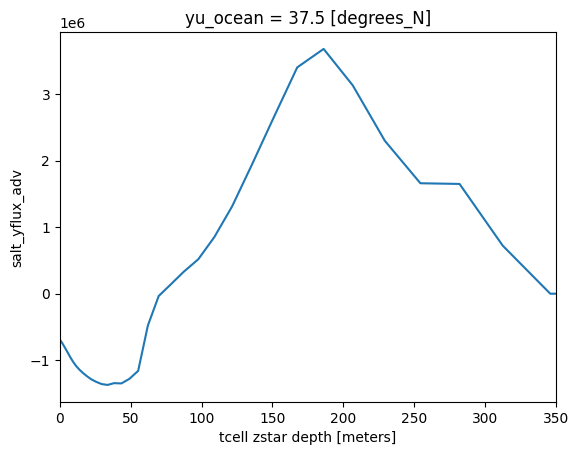

In [29]:
salt_flux.salt_yflux_adv.plot(xlim=(0,350))

In [5]:
topo_om2 = xr.open_mfdataset('/g/data/ik11/inputs/access-om2/input_b72797e1/mom_01deg/topog.nc', coords = "minimal", compat="override",engine="netcdf4")

In [32]:
esm1_6_TOPO = xr.open_mfdataset('/scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output640/ocean/ocean-2d-hu.nc',coords = "minimal", compat="override",engine="netcdf4")

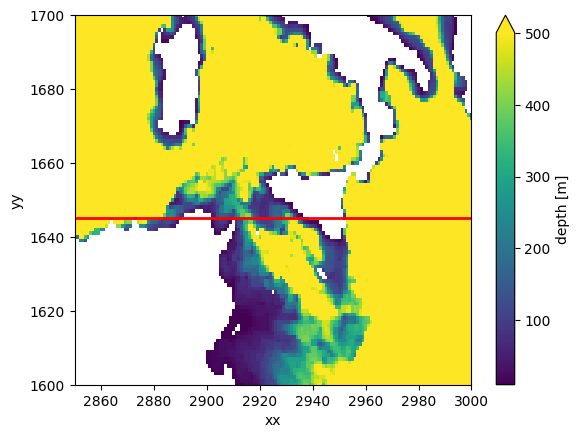

In [19]:
topo_om2.depth.plot(xlim=(2850,3000),ylim=(1600,1700),vmax=500)
plt.hlines(y=1645, xmin=2850, xmax=3000, colors='red', linewidth=2)

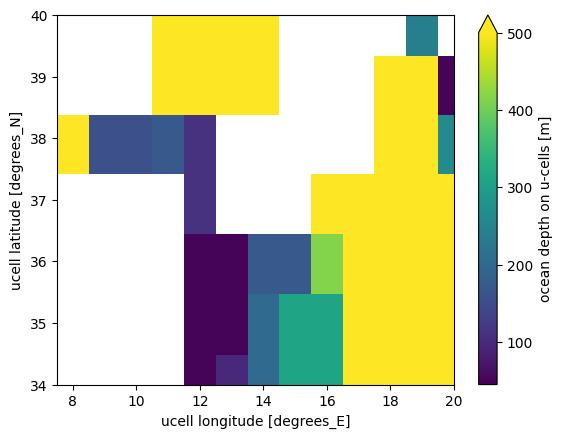

In [16]:
esm1_6_TOPO.hu.plot(xlim=(7.5,20),ylim=(34,40),vmax=500)

In [17]:
esm1_6_TOPO = xr.open_mfdataset('/scratch/p66/jxs599/access-esm/archive/AprilSpinUp-AprilSpinUp-56aae814/output640/ocean/ocean-2d-ht.nc',coords = "minimal", compat="override",engine="netcdf4")

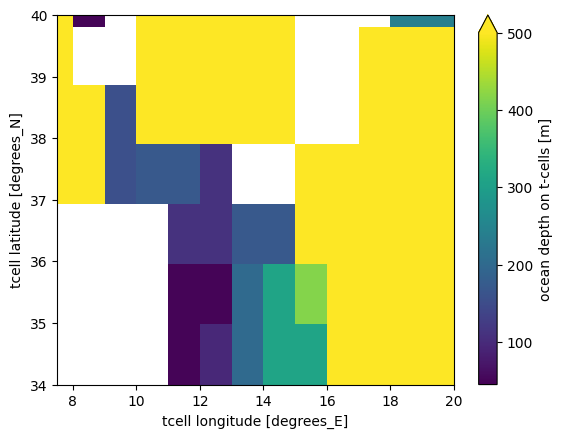

In [18]:
esm1_6_TOPO.ht.plot(xlim=(7.5,20),ylim=(34,40),vmax=500)

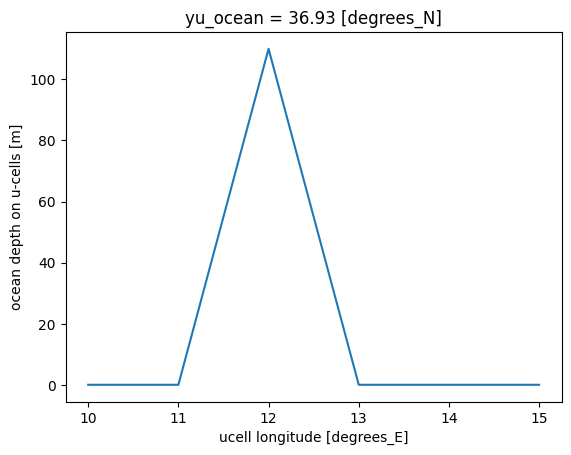

In [38]:
esm1_6_TOPO.hu.sel(yu_ocean=37,method='nearest').sel(xu_ocean=slice(10,15)).fillna(0).plot()

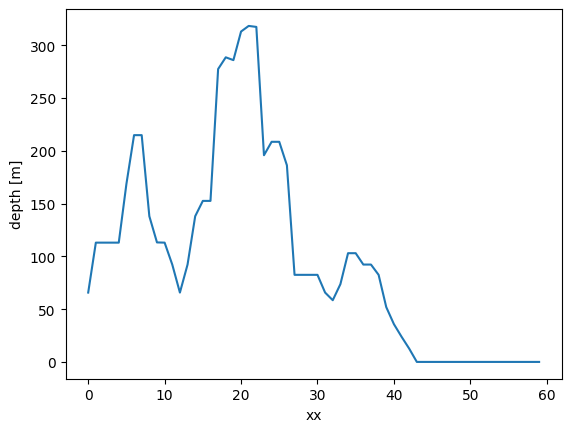

In [43]:
topo_om2.depth.isel(yy=1649).sel(xx=slice(2890,2950)).fillna(0).plot()

In [44]:
catalog.search(model="ACCESS-OM2", variable="salt_yflux_adv")

NameError: name 'catalog' is not defined

In [ ]:
experiment = "01deg_jra55v140_iaf_cycle4_jra55v150_extension"
variable = "salt_yflux_adv"
ACCESS_OM2_salt_yflux_adv = catalog[experiment].search(
    variable=variable).to_dask()

In [46]:
topo_om2_1deg = xr.open_mfdataset('/g/data/ik11/inputs/access-om2/input_b72797e1/mom_1deg/topog.nc', coords = "minimal", compat="override",engine="netcdf4")

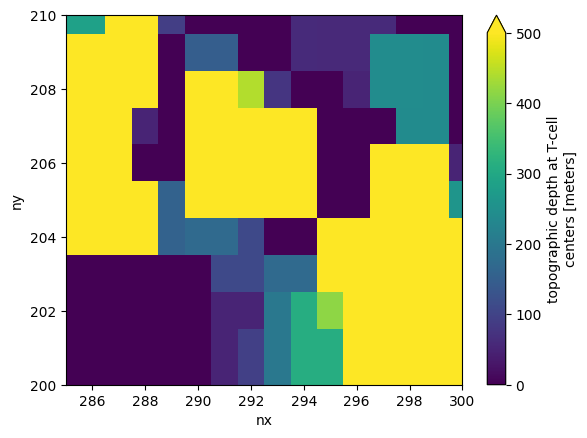

In [51]:
topo_om2_1deg.depth.plot(xlim=(285,300),ylim=(200,210),vmax=500)